# **Interpretabilidad — LIME**

LIME (*Local Interpretable Model-agnostic Explanations*) explica **predicciones individuales**
de cualquier modelo caja negra localmente .

## **Instalación y Configuración del Explainer**

In [ ]:
!pip install lime --quiet

import lime
import lime.lime_tabular
from sklearn.metrics import confusion_matrix

# ── Reconstruir nombres de features categóricas para LIME ────────────────────
# LIME necesita saber qué posiciones del vector son categóricas (OHE)
ohe_feature_names = preprocessor.named_transformers_['cat'] \
                    .get_feature_names_out(CAT_FEATURES).tolist()
all_feature_names  = NUM_FEATURES + ohe_feature_names

# Índices de las features categóricas (OHE) en el vector final
cat_indices = list(range(len(NUM_FEATURES), len(all_feature_names)))

# ── LimeTabularExplainer ─────────────────────────────────────────────────────
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data   = X_train_sk,
    feature_names   = all_feature_names,
    class_names     = ['Fully Paid', 'Charged Off'],
    categorical_features = cat_indices,
    mode            = 'classification',
    random_state    = 42
)

print(f'LimeTabularExplainer configurado')
print(f'  Features totales     : {len(all_feature_names)}')
print(f'  Features numéricas   : {len(NUM_FEATURES)}')
print(f'  Features categóricas : {len(cat_indices)}')

LimeTabularExplainer configurado
  Features totales     : 77
  Features numéricas   : 6
  Features categóricas : 71


## **Selección de Instancias Mal Clasificadas**

In [ ]:
y_pred      = best_model.predict(X_test_sk)
y_pred_prob = best_model.predict_proba(X_test_sk)[:, 1]

import numpy as np

# Índices de errores
fp_idx = np.where((y_pred == 1) & (y_test.values == 0))[0]  # Falsos Positivos
fn_idx = np.where((y_pred == 0) & (y_test.values == 1))[0]  # Falsos Negativos

# Seleccionar la instancia con probabilidad más cercana al umbral en cada grupo
# — son los casos más 'confusos' para el modelo y los más informativos para LIME
fp_instance_idx = fp_idx[np.argmin(np.abs(y_pred_prob[fp_idx] - 0.5))]
fn_instance_idx = fn_idx[np.argmin(np.abs(y_pred_prob[fn_idx] - 0.5))]

print(f'Falsos Positivos totales : {len(fp_idx):,}')
print(f'Falsos Negativos totales : {len(fn_idx):,}')
print(f'\nInstancia FP seleccionada (idx={fp_instance_idx})')
print(f'  Real: Fully Paid (0)  |  Predicho: Charged Off (1)  |  P(default)={y_pred_prob[fp_instance_idx]:.4f}')
print(f'\nInstancia FN seleccionada (idx={fn_instance_idx})')
print(f'  Real: Charged Off (1)  |  Predicho: Fully Paid (0)  |  P(default)={y_pred_prob[fn_instance_idx]:.4f}')

Falsos Positivos totales : 59
Falsos Negativos totales : 53,599

Instancia FP seleccionada (idx=227654)
  Real: Fully Paid (0)  |  Predicho: Charged Off (1)  |  P(default)=0.5002

Instancia FN seleccionada (idx=22902)
  Real: Charged Off (1)  |  Predicho: Fully Paid (0)  |  P(default)=0.4999


Estas selecciones no sonn casualidad ni arbitrarias, se seleccionaron explícitamente como los casos más cercanos a 0.5 para maximizar la informatividad de la explicación. Son los préstamos donde el modelo estuvo más confuso.

## **Explicación — Falso Positivo (pagó bien pero fue predicho como default)**

Préstamo que **pagó correctamente** pero el modelo predijo como *default*.
Las variables en rojo empujaron la predicción hacia *Charged Off*;
las azules la empujaron hacia *Fully Paid*.

── Falso Positivo — P(Charged Off) = 0.5002 ──
Real: Fully Paid (0)  |  Predicho: Charged Off (1)

                  Feature  Contribución             Dirección
          int_rate > 0.58      0.119701 → Charged Off (error)
 purpose_small_business=0     -0.044888          → Fully Paid
               dti > 0.71      0.036017 → Charged Off (error)
 fico_range_high <= -0.82      0.031198 → Charged Off (error)
          addr_state_VT=0     -0.028426          → Fully Paid
home_ownership_MORTGAGE=0      0.023594 → Charged Off (error)
      annual_inc <= -0.61      0.022094 → Charged Off (error)
          addr_state_NH=0      0.020740 → Charged Off (error)
          addr_state_NE=0     -0.020081          → Fully Paid
        purpose_wedding=0      0.018348 → Charged Off (error)


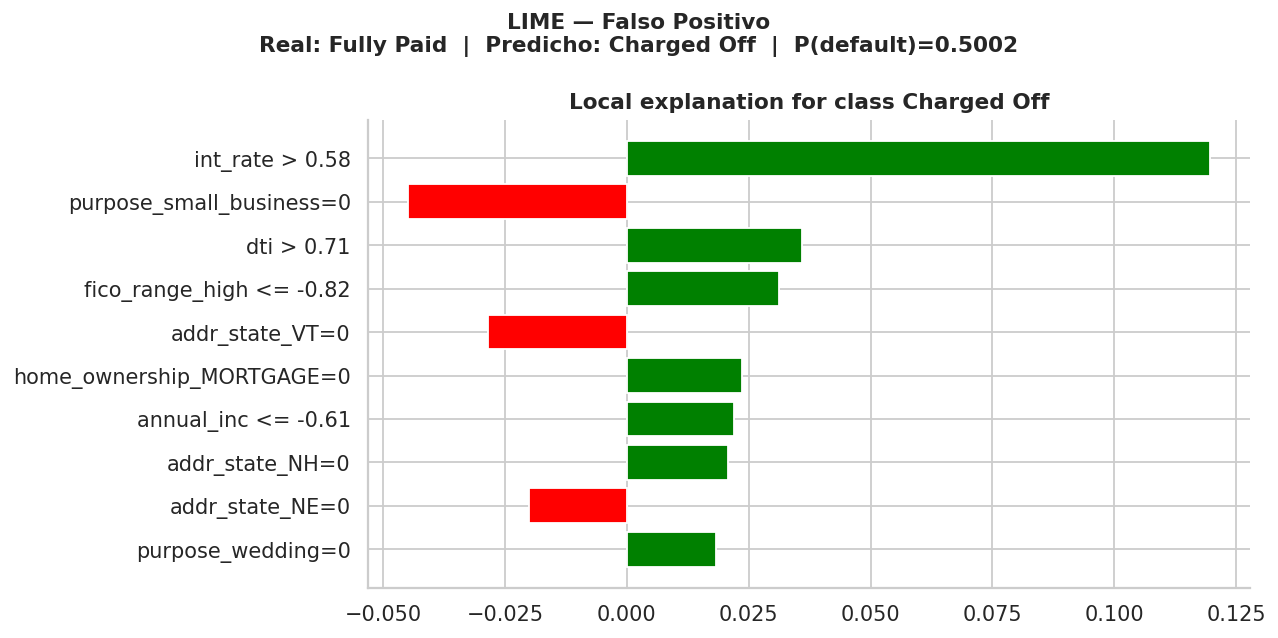

In [ ]:
exp_fp = explainer.explain_instance(
    data_row       = X_test_sk[fp_instance_idx],
    predict_fn     = best_model.predict_proba,
    num_features   = 10,
    labels         = (1,)   # explicar la clase 'Charged Off'
)

print(f'── Falso Positivo — P(Charged Off) = {y_pred_prob[fp_instance_idx]:.4f} ──')
print(f'Real: Fully Paid (0)  |  Predicho: Charged Off (1)\n')

# Tabla de contribuciones
fp_contributions = exp_fp.as_list(label=1)
fp_df = pd.DataFrame(fp_contributions, columns=['Feature', 'Contribución'])
fp_df['Dirección'] = fp_df['Contribución'].apply(
    lambda x: '→ Charged Off (error)' if x > 0 else '→ Fully Paid'
)
print(fp_df.to_string(index=False))

# Gráfico
fig = exp_fp.as_pyplot_figure(label=1)
fig.set_size_inches(10, 5)
fig.suptitle('LIME — Falso Positivo\n'
             f'Real: Fully Paid  |  Predicho: Charged Off  |  P(default)={y_pred_prob[fp_instance_idx]:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

int_rate > 0.58 es la contribución más fuerte hacia Charged Off (0.12), seguida de dti > 0.71 y fico_range_high <= -0.82. El modelo fue penalizado por una tasa de interés alta y un DTI elevado, variables que estadísticamente predicen default, pero este préstamo particular fue pagado.

## **Explicación — Falso Negativo (hizo default pero fue predicho como pagado)**

Préstamo que **hizo default** pero el modelo predijo como *Fully Paid*.
Este es el error más costoso desde el punto de vista financiero.

── Falso Negativo — P(Charged Off) = 0.4999 ──
Real: Charged Off (1)  |  Predicho: Fully Paid (0)

                 Feature  Contribución            Dirección
         int_rate > 0.58      0.119606        → Charged Off
         addr_state_ND=0     -0.041748 → Fully Paid (error)
    home_ownership_ANY=0      0.041378        → Charged Off
purpose_small_business=0     -0.040409 → Fully Paid (error)
              dti > 0.71      0.038381        → Charged Off
        loan_amnt > 0.64      0.036759        → Charged Off
      purpose_vacation=0     -0.027514 → Fully Paid (error)
         addr_state_AR=0     -0.025360 → Fully Paid (error)
         addr_state_ME=0      0.025199        → Charged Off
   purpose_educational=0      0.013747        → Charged Off


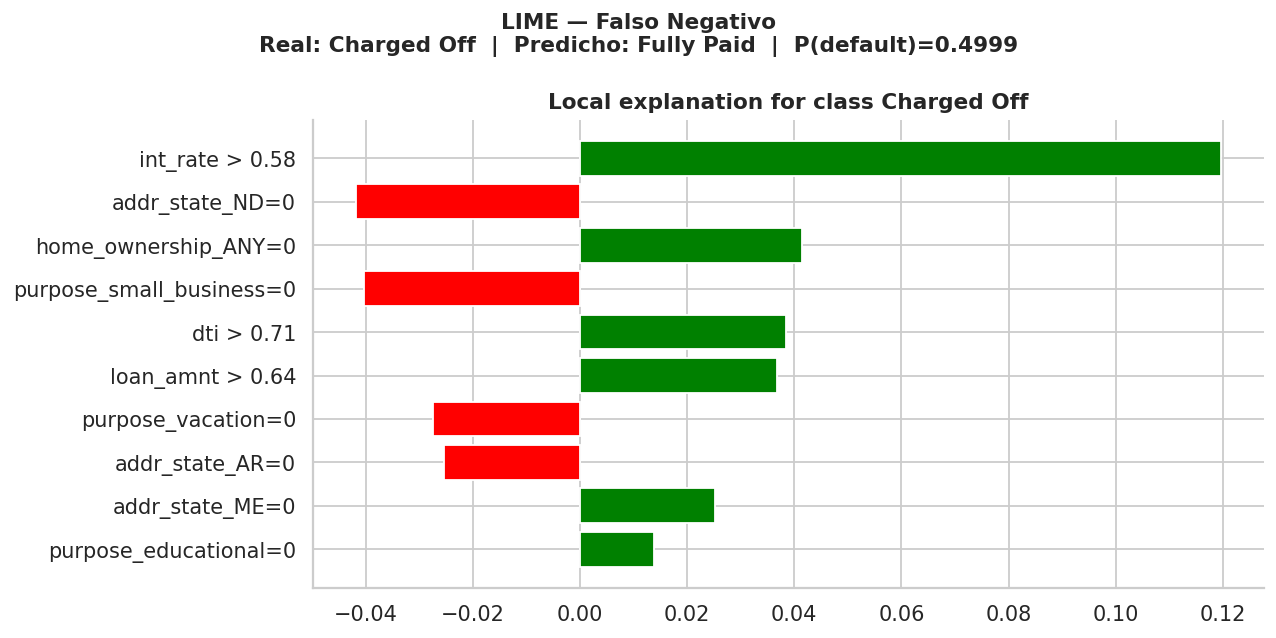

In [ ]:
exp_fn = explainer.explain_instance(
    data_row       = X_test_sk[fn_instance_idx],
    predict_fn     = best_model.predict_proba,
    num_features   = 10,
    labels         = (1,)   # explicar la clase 'Charged Off'
)

print(f'── Falso Negativo — P(Charged Off) = {y_pred_prob[fn_instance_idx]:.4f} ──')
print(f'Real: Charged Off (1)  |  Predicho: Fully Paid (0)\n')

# Tabla de contribuciones
fn_contributions = exp_fn.as_list(label=1)
fn_df = pd.DataFrame(fn_contributions, columns=['Feature', 'Contribución'])
fn_df['Dirección'] = fn_df['Contribución'].apply(
    lambda x: '→ Charged Off' if x > 0 else '→ Fully Paid (error)'
)
print(fn_df.to_string(index=False))

# Gráfico
fig = exp_fn.as_pyplot_figure(label=1)
fig.set_size_inches(10, 5)
fig.suptitle('LIME — Falso Negativo\n'
             f'Real: Charged Off  |  Predicho: Fully Paid  |  P(default)={y_pred_prob[fn_instance_idx]:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

int_rate > 0.58 también lidera hacia Charged Off (0.12), pero múltiples variables de estado (addr_state_ND=0, addr_state_AR=0) empujaron hacia Fully Paid con fuerza suficiente para cruzar el umbral, estas variables tienen contribuciones negativas porque el modelo aprendió que ciertos estados tienen tasas de default más bajas, y la ausencia de esos estados empuja hacia riesgo.

## **Comparación de Contribuciones — FP vs FN**

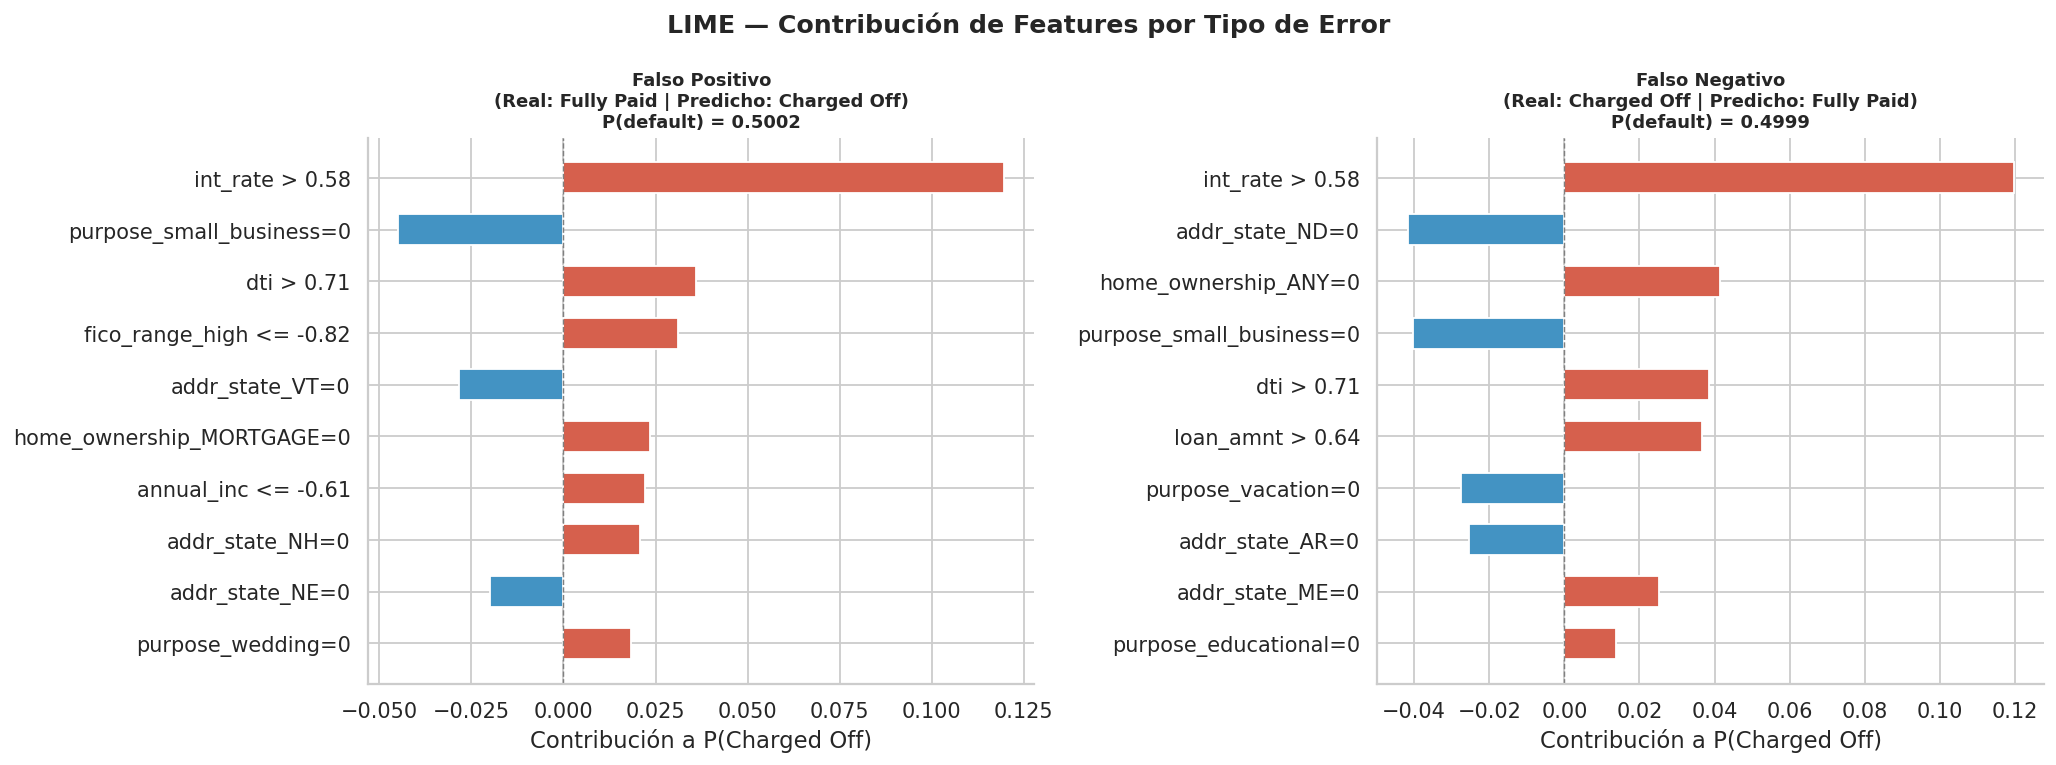

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LIME — Contribución de Features por Tipo de Error', fontsize=14, fontweight='bold')

for ax, contributions, title, pred_prob in zip(
    axes,
    [fp_contributions, fn_contributions],
    ['Falso Positivo\n(Real: Fully Paid | Predicho: Charged Off)',
     'Falso Negativo\n(Real: Charged Off | Predicho: Fully Paid)'],
    [y_pred_prob[fp_instance_idx], y_pred_prob[fn_instance_idx]]
):
    features = [x[0] for x in contributions]
    values   = [x[1] for x in contributions]
    colors   = [C_DEFAULT if v > 0 else C_PAID for v in values]

    ax.barh(features[::-1], values[::-1], color=colors[::-1],
            edgecolor='white', height=0.6)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'{title}\nP(default) = {pred_prob:.4f}', fontsize=10)
    ax.set_xlabel('Contribución a P(Charged Off)')

plt.tight_layout()
plt.show()

**Patrón común**
En ambas instancias int_rate es la variable más influyente, coherente con su 44.9% de importancia global. LIME confirma a nivel local lo que la importancia de features muestra globalmente. Esto da confianza en que el modelo no está usando correlaciones casuales. La variable más importante es también la más intuitiva desde el punto de vista financiero.

# **Reflexion Final**
Ambos frameworks llegaron a la misma conclusión sobre el espacio de hiperparámetros. La diferencia de rendimiento es despreciable. La diferencia de tiempo es sustancial, PySpark tardó más del doble en el grid search y 17 veces más en predicción.
Esto no significa que PySpark sea inferior. Significa que en un entorno local de una sola máquina, el overhead supera sus beneficios. PySpark cobra sentido cuando el dataset no cabe en memoria de un solo nodo o cuando existe un cluster distribuido real. Para este problema en este entorno, sklearn es la herramienta correcta.